**Purpose:** Magnimind machine-learning lesson notebook: Military.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_excel("World military power.xlsx")

In [3]:
df

,Military Strength,Military Strength Power Index,Aircraft Strength,Aircraft Strength value,Fighter/Interceptor Strength,Fighter/Interceptor Strength value,Attack Aircraft Strength,Attack Aircraft Strength value,Transport Aircraft Fleet Strength,Transport Aircraft Fleet Strength value,...,Total Population,Total Population value,Total Square Land Area,Total Square Land Area value,Total Coastline Coverage,Total Coastline Coverage value,Total Waterway Coverage,Total Waterway Coverage value,Total Border Coverage,Total Border Coverage value
0,Afghanistan,1.3444,Afghanistan,260,Afghanistan,0,Afghanistan,25,Afghanistan,30,...,Afghanistan,"3,49,40,837",Afghanistan,"6,52,230",Afghanistan,0,Afghanistan,1200,Afghanistan,5987.0
1,Albania,2.3137,Albania,19,Albania,0,Albania,0,Albania,0,...,Albania,"30,57,220",Albania,28748,Albania,362,Albania,41,Albania,691.0
2,Algeria,0.4659,Algeria,551,Algeria,103,Algeria,22,Algeria,59,...,Algeria,"4,16,57,488",Algeria,"23,81,741",Algeria,998,Algeria,0,Algeria,6734.0
3,Angola,0.8379,Angola,295,Angola,72,Angola,18,Angola,30,...,Angola,"3,03,55,880",Angola,"12,46,700",Angola,1600,Angola,1300,Angola,5369.0
4,Argentina,0.6521,Argentina,227,Argentina,24,Argentina,7,Argentina,9,...,Argentina,"4,46,94,198",Argentina,"27,80,400",Argentina,4989,Argentina,11000,Argentina,11968.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133,Venezuela,0.6449,Venezuela,260,Venezuela,38,Venezuela,0,Venezuela,52,...,Venezuela,"3,16,89,176",Venezuela,"9,12,050",Venezuela,2800,Venezuela,7100,Venezuela,5267.0
134,Vietnam,0.3559,Vietnam,293,Vietnam,77,Vietnam,0,Vietnam,38,...,Vietnam,"9,70,40,334",Vietnam,"3,31,210",Vietnam,3444,Vietnam,17702,Vietnam,4616.0
135,Yemen,1.2412,Yemen,169,Yemen,77,Yemen,0,Yemen,8,...,Yemen,"2,86,67,230",Yemen,"5,27,968",Yemen,1906,Yemen,0,Yemen,1601.0
136,Zambia,1.6464,Zambia,108,Zambia,18,Zambia,0,Zambia,11,...,Zambia,"1,64,45,079",Zambia,"7,52,618",NaN,NaN,Zambia,2250,Zambia,6043.0


In [4]:
real_df = df.iloc[:,  range(1, len(df.columns),2)]
real_df["Country"] = df.iloc[:,0]

C:\Users\hskay\AppData\Local\Temp\ipykernel_21476\2171788349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  real_df["Country"] = df.iloc[:,0]


In [5]:
real_df.head().T

,0,1,2,3,4
Military Strength Power Index,1.3444,2.3137,0.4659,0.8379,0.6521
Aircraft Strength value,260,19,551,295,227
Fighter/Interceptor Strength value,0,0,103,72,24
Attack Aircraft Strength value,25,0,22,18,7
Transport Aircraft Fleet Strength value,30,0,59,30,9
Trainer Aircraft Fleet value,0,0,87,47,64
Helicopter Fleet Strength value,187,19,257,126,100
Attack Helicopter Fleet Strength value,0,0,45,15,0
Tank Strength value,0,0,880,379,370
AFV/APC Strength value,1062,467,7361,595,739


In [6]:
real_df = real_df.replace(',', '', regex=True)
real_df.iloc[:,:-1] = real_df.iloc[:,:-1].astype(float)

In [7]:
real_df.head().T

,0,1,2,3,4
Military Strength Power Index,1.3444,2.3137,0.4659,0.8379,0.6521
Aircraft Strength value,260.0,19.0,551.0,295.0,227.0
Fighter/Interceptor Strength value,0.0,0.0,103.0,72.0,24.0
Attack Aircraft Strength value,25.0,0.0,22.0,18.0,7.0
Transport Aircraft Fleet Strength value,30.0,0.0,59.0,30.0,9.0
Trainer Aircraft Fleet value,0.0,0.0,87.0,47.0,64.0
Helicopter Fleet Strength value,187.0,19.0,257.0,126.0,100.0
Attack Helicopter Fleet Strength value,0.0,0.0,45.0,15.0,0.0
Tank Strength value,0.0,0.0,880.0,379.0,370.0
AFV/APC Strength value,1062.0,467.0,7361.0,595.0,739.0


In [8]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans())
])

param_grid = {
    'kmeans__n_clusters': [2, 3, 4, 5],
    'kmeans__init': ['k-means++', 'random']
    }

In [9]:
grid_search = GridSearchCV(pipeline, param_grid, cv=3, n_jobs=-1, verbose=2)

In [10]:
real_df[real_df.isnull().sum(axis = 1) > 0]

,Military Strength Power Index,Aircraft Strength value,Fighter/Interceptor Strength value,Attack Aircraft Strength value,Transport Aircraft Fleet Strength value,Trainer Aircraft Fleet value,Helicopter Fleet Strength value,Attack Helicopter Fleet Strength value,Tank Strength value,AFV/APC Strength value,...,Oil Production value,Oil Consumption value,Proven Oil Reserves value,Available Manpower value,Total Population value,Total Square Land Area value,Total Coastline Coverage value,Total Waterway Coverage value,Total Border Coverage value,Country
5,2.1251,64.0,0.0,9.0,3.0,13.0,37.0,20.0,110.0,748.0,...,0.0,47500.0,0.0,1696085.0,3038217.0,29743.0,NaN,0.0,1570.0,Armenia
6,0.3225,464.0,82.0,6.0,38.0,174.0,133.0,22.0,59.0,3051.0,...,263000.0,1005000.0,1821000000.0,10808002.0,23470145.0,7741220.0,25760.0,2000.0,NaN,Australia
7,0.9568,120.0,15.0,0.0,11.0,32.0,62.0,0.0,56.0,467.0,...,14260.0,215000.0,43000000.0,4017691.0,8793370.0,83871.0,NaN,0.0,2524.0,Austria
9,1.8547,109.0,17.0,0.0,2.0,37.0,65.0,22.0,180.0,843.0,...,45000.0,55000.0,124600000.0,806505.0,1422659.0,760.0,161.0,0.0,NaN,Bahrain
11,0.8179,202.0,39.0,68.0,4.0,28.0,63.0,21.0,532.0,1560.0,...,32000.0,190000.0,198000000.0,4982905.0,9527543.0,207600.0,NaN,2500.0,3599.0,Belarus
13,10.1681,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,27.0,...,0.0,2000.0,0.0,176808.0,766397.0,38394.0,NaN,0.0,1136.0,Bhutan
14,0.9942,69.0,0.0,0.0,14.0,23.0,38.0,0.0,54.0,137.0,...,59330.0,60000.0,211500000.0,5075416.0,11306341.0,1098581.0,NaN,10000.0,7252.0,Bolivia
16,2.0582,45.0,10.0,0.0,11.0,8.0,16.0,0.0,55.0,245.0,...,0.0,16500.0,0.0,962617.0,2249104.0,581730.0,NaN,0.0,4347.0,Botswana
19,1.9009,16.0,0.0,3.0,1.0,4.0,8.0,2.0,0.0,350.0,...,0.0,10500.0,0.0,7800000.0,19742715.0,274200.0,NaN,0.0,3611.0,Burkina Faso
23,3.2889,3.0,0.0,0.0,2.0,0.0,1.0,0.0,4.0,55.0,...,0.0,4500.0,0.0,2348581.0,5745062.0,622984.0,NaN,2800.0,5920.0,Central African Republic


In [11]:
real_df["Navy Fleet Strengths value"].describe()

count    124.000000
mean      84.983871
std      146.114165
min        0.000000
25%       10.000000
50%       38.000000
75%       77.750000
max      984.000000
Name: Navy Fleet Strengths value, dtype: float64

In [12]:
real_df_t = real_df.iloc[:,:-1].fillna(real_df.iloc[:,:-1].mean())

In [13]:
real_df_t.isnull().sum().sum()

0

In [14]:
real_df_t["Country"] = real_df["Country"]

In [15]:
real_df_t.columns

Index(['Military Strength Power Index', 'Aircraft Strength value',
       'Fighter/Interceptor Strength value', 'Attack Aircraft Strength value',
       'Transport Aircraft Fleet Strength value',
       'Trainer Aircraft Fleet value', 'Helicopter Fleet Strength value',
       'Attack Helicopter Fleet Strength value', 'Tank Strength value',
       'AFV/APC Strength value', 'Self-Propelled Artillery Strength value',
       'Towed Artillery Strength value', 'Rocket Projector Strength value',
       'Navy Fleet Strengths value', 'Aircraft Carrier Fleet Strength value',
       'Submarine Fleet Strength value', 'Destroyer Fleet Strength value',
       'Frigate Fleet Strength value', 'defense spending budget value',
       'External Debt value', 'Airport Totals value', 'Oil Production value',
       'Oil Consumption value', 'Proven Oil Reserves value',
       'Available Manpower value', 'Total Population value',
       'Total Square Land Area value', 'Total Coastline Coverage value',
       '

In [16]:
grid_search.fit(real_df_t.iloc[:,:-1])
grid_search.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits


{'kmeans__init': 'random', 'kmeans__n_clusters': 4}

In [17]:
real_df_t["Cluster"]=grid_search.best_estimator_.named_steps['kmeans'].labels_

In [18]:
import seaborn as sns

sns.pairplot(real_df_t, hue="Cluster")

In [19]:

correlation_matrix_real_df_t = real_df_t.iloc[:,:-2].corr()

In [20]:
plt.figure(figsize=(120, 100))
sns.heatmap(correlation_matrix_real_df_t, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [21]:
X = real_df_t.iloc[:,:-2].values

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [23]:
hc_ward = linkage(y = X, method = "ward")
hc_complete = linkage(X, "complete")
hc_average = linkage(X, "average")
hc_single = linkage(X, "single")

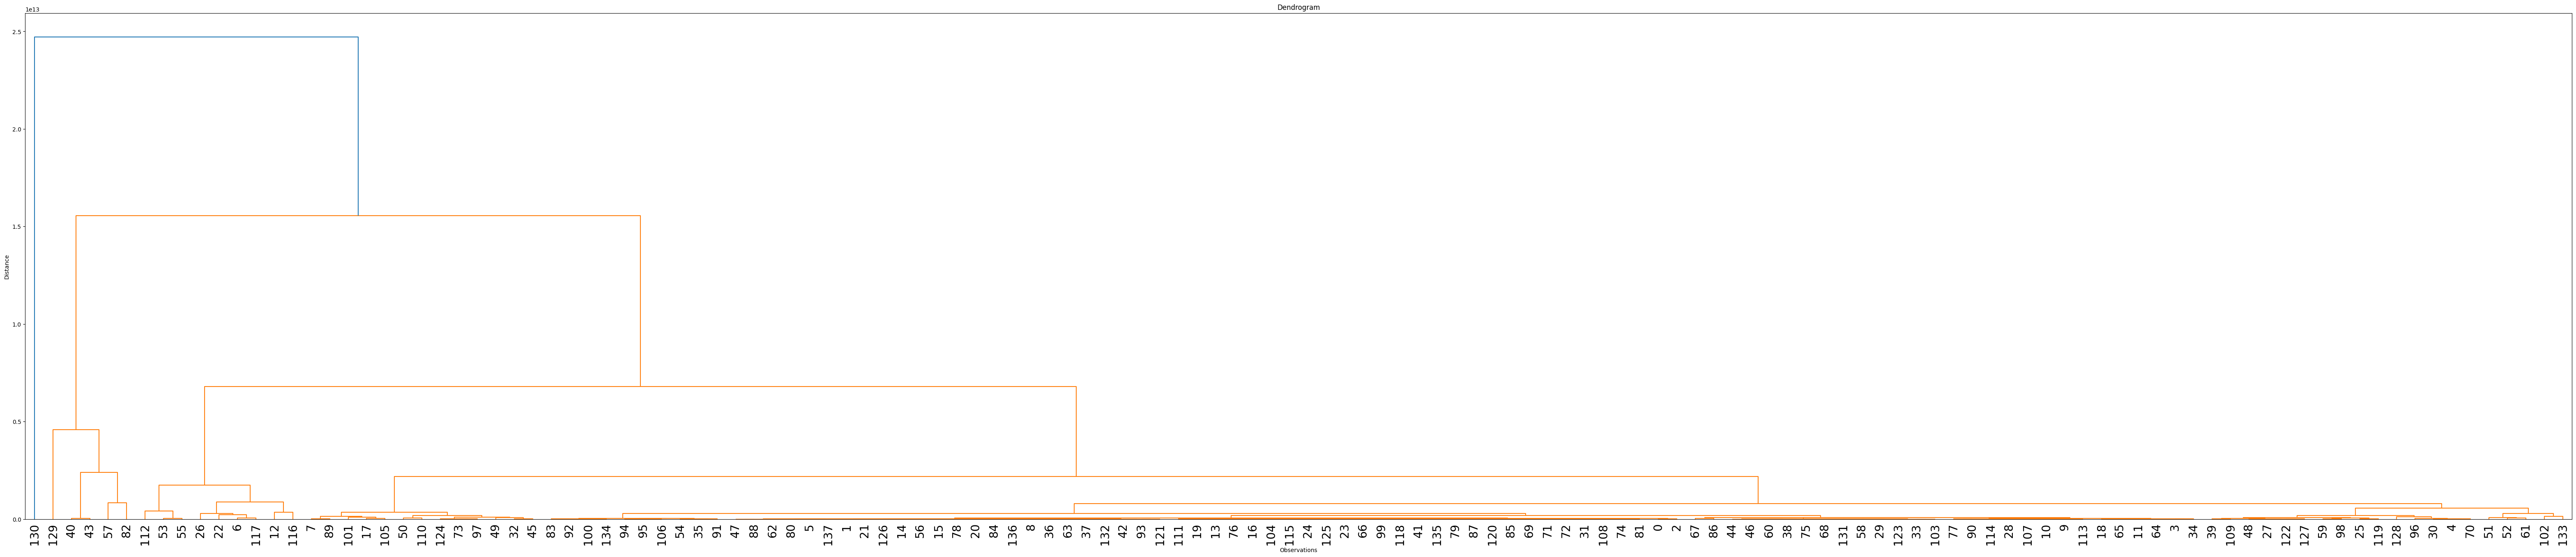

In [24]:
plt.figure(figsize = (80,16))
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, leaf_font_size = 20,);

In [25]:
real_df_t.loc[130,"Country"]

'United States'

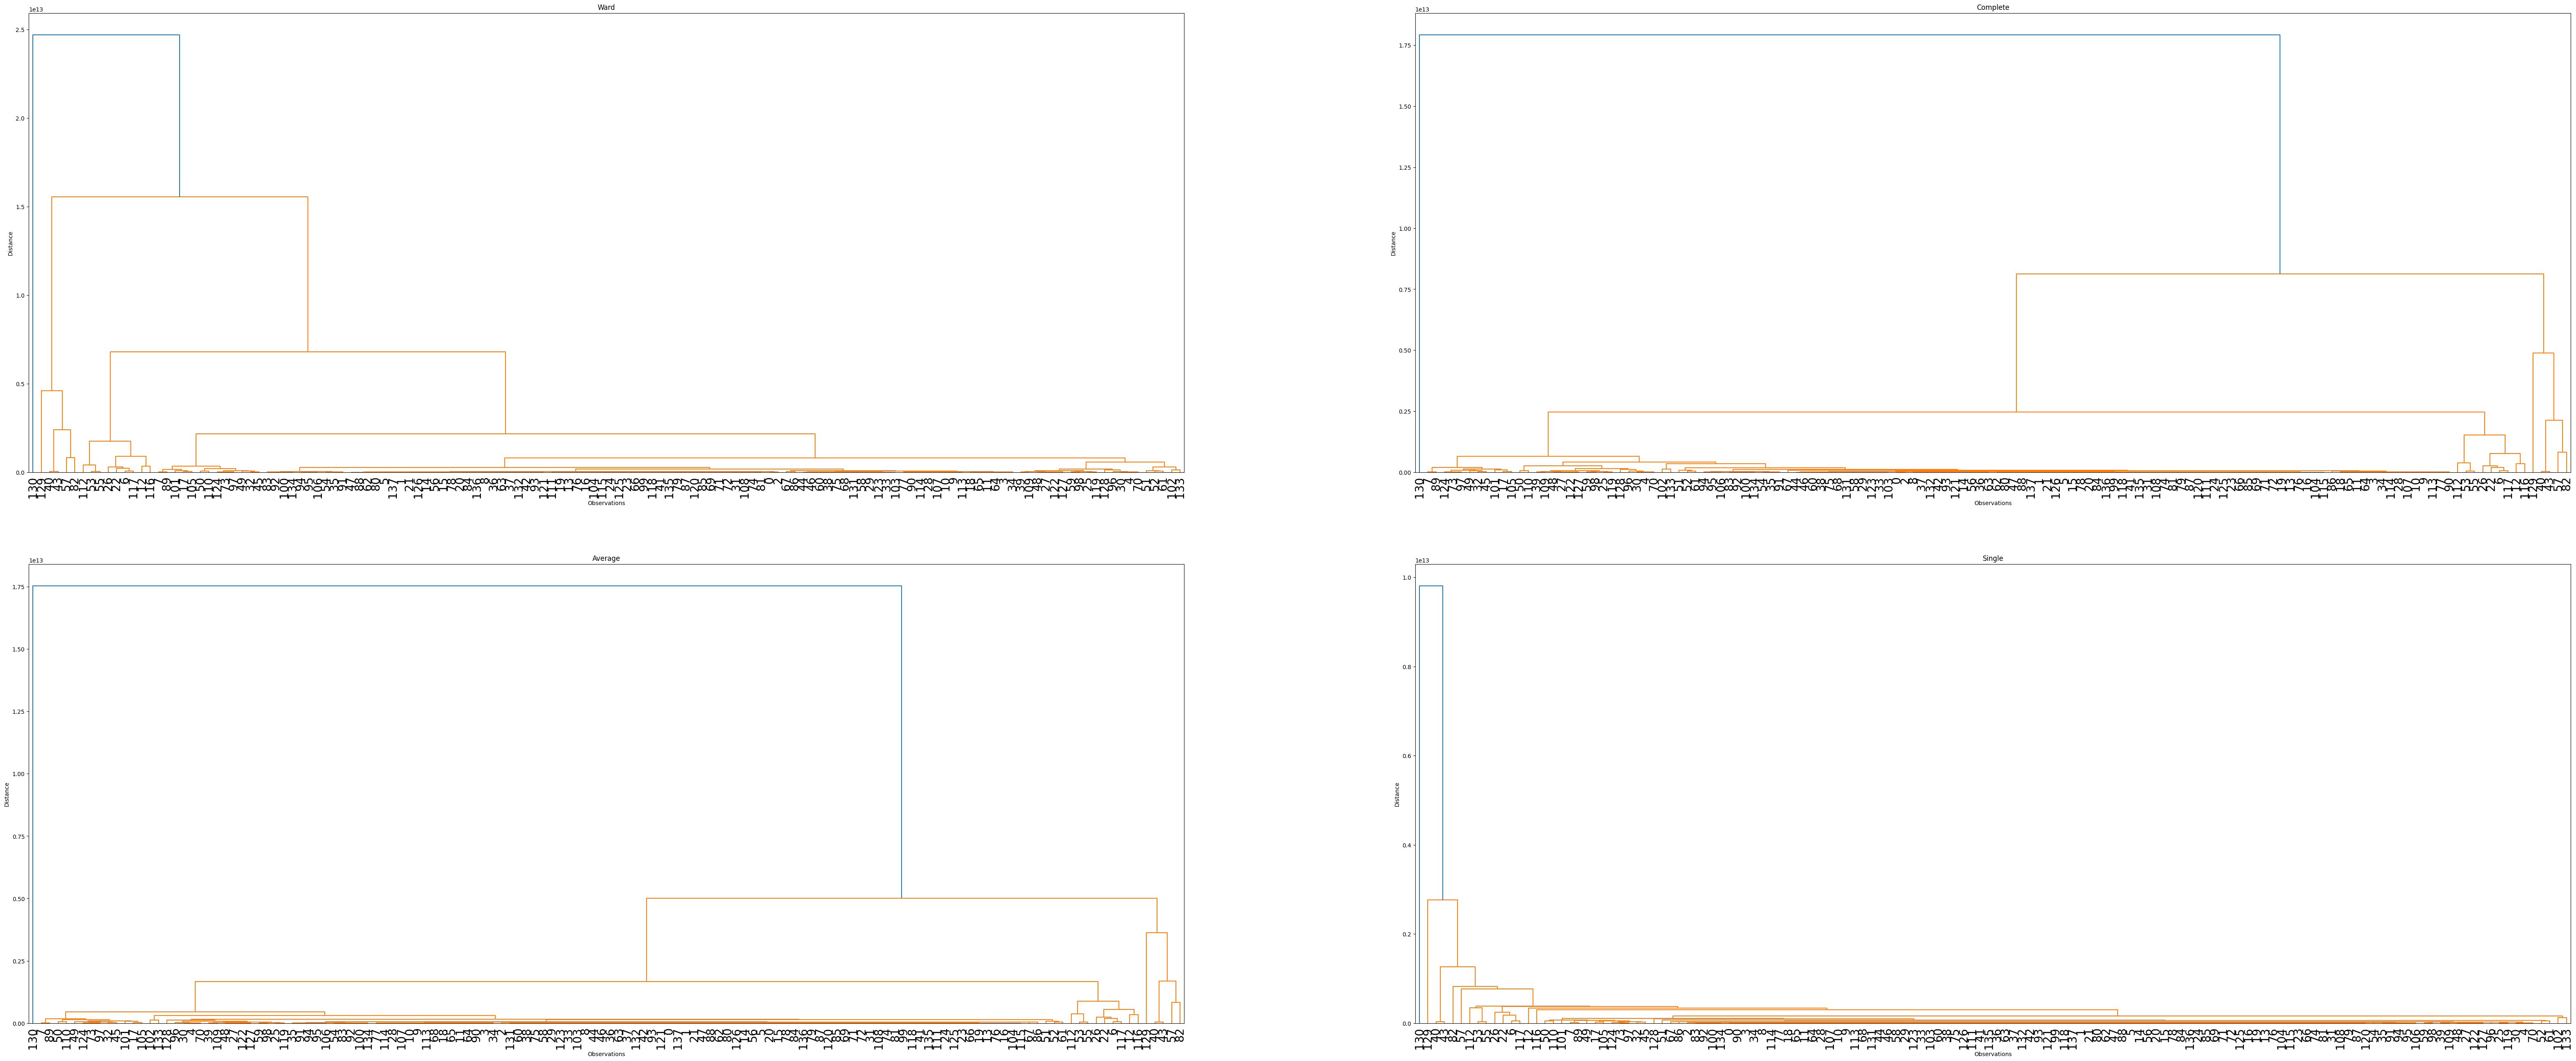

In [26]:
plt.figure(figsize = (80,32))
plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, leaf_font_size = 20)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete, leaf_font_size = 20)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average, leaf_font_size = 20)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single, leaf_font_size = 20);

In [27]:
X = real_df_t.iloc[:,:-2].values
X = np.delete(X, 130, axis=0)

In [28]:
hc_ward = linkage(y = X, method = "ward")
hc_complete = linkage(X, "complete")
hc_average = linkage(X, "average")
hc_single = linkage(X, "single")

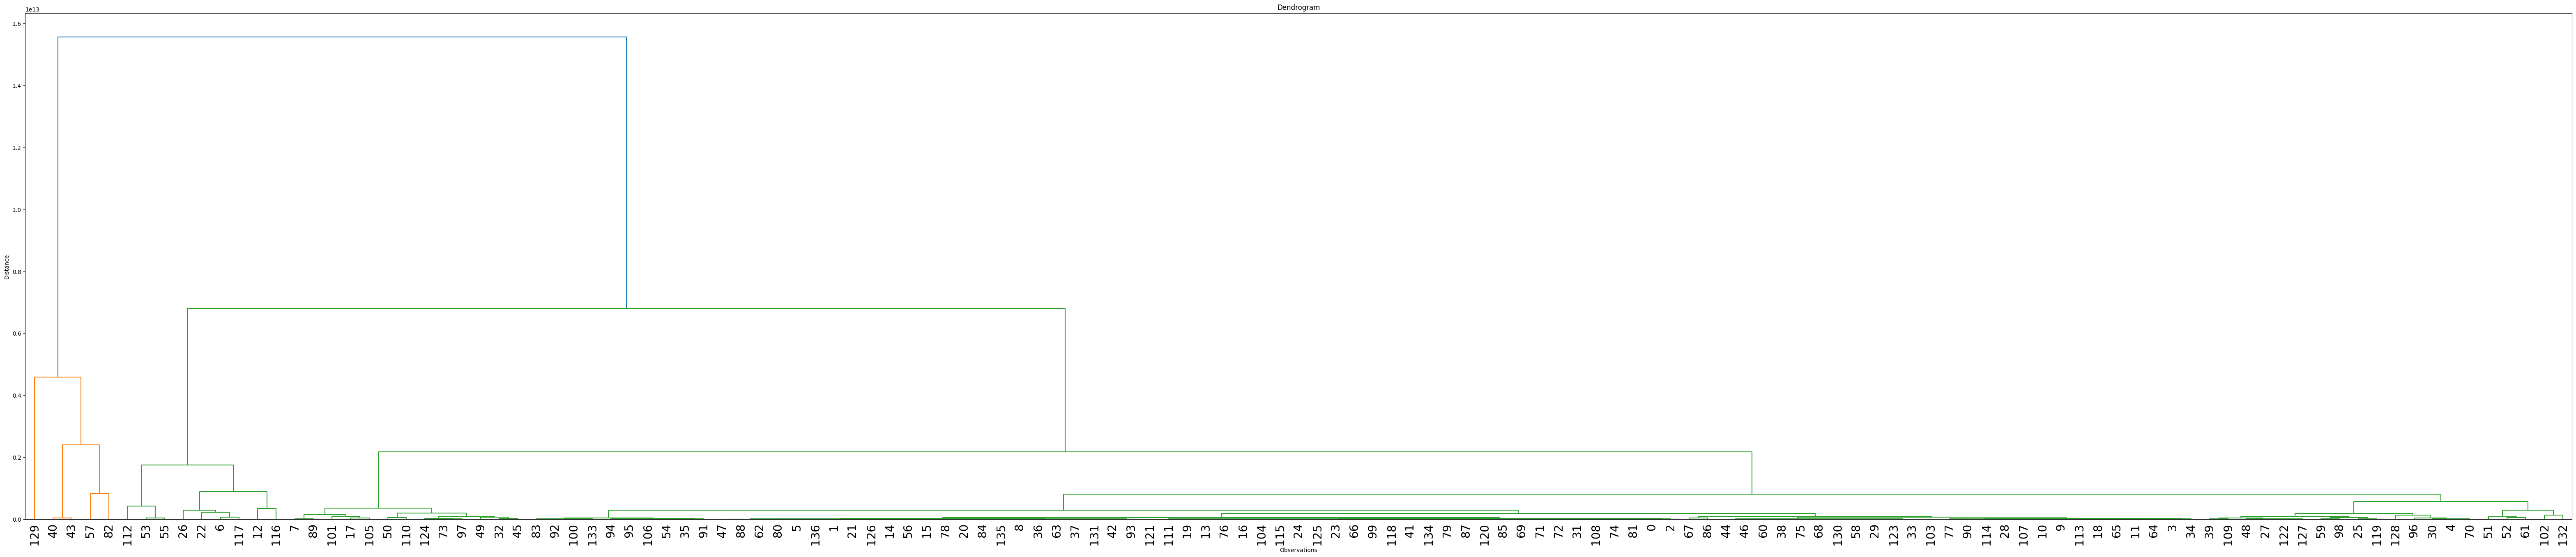

In [29]:
plt.figure(figsize = (80,16))
plt.title("Dendrogram")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, leaf_font_size = 20,);

In [30]:
hc_ward = linkage(y = X, method = "ward")
hc_complete = linkage(X, "complete")
hc_average = linkage(X, "average")
hc_single = linkage(X, "single")


In [31]:
X[129]

array([1.7170000e-01, 7.3300000e+02, 1.3300000e+02, 1.5000000e+01,
       4.4000000e+01, 2.4100000e+02, 3.1200000e+02, 4.9000000e+01,
       2.2700000e+02, 5.0000000e+03, 8.9000000e+01, 1.2600000e+02,
       3.5000000e+01, 8.8000000e+01, 2.0000000e+00, 1.0000000e+01,
       6.0000000e+00, 1.3000000e+01, 5.5100000e+10, 8.1260000e+12,
       4.6000000e+02, 9.1050000e+05, 1.6000000e+06, 2.5640000e+09,
       2.9948413e+07, 6.5105246e+07, 2.4361000e+05, 1.2429000e+04,
       3.2000000e+03, 4.4300000e+02])

In [32]:
real_df_t.loc[129,"Country"]

'United Kingdom'

In [33]:
X = np.delete(X, 129, axis=0)

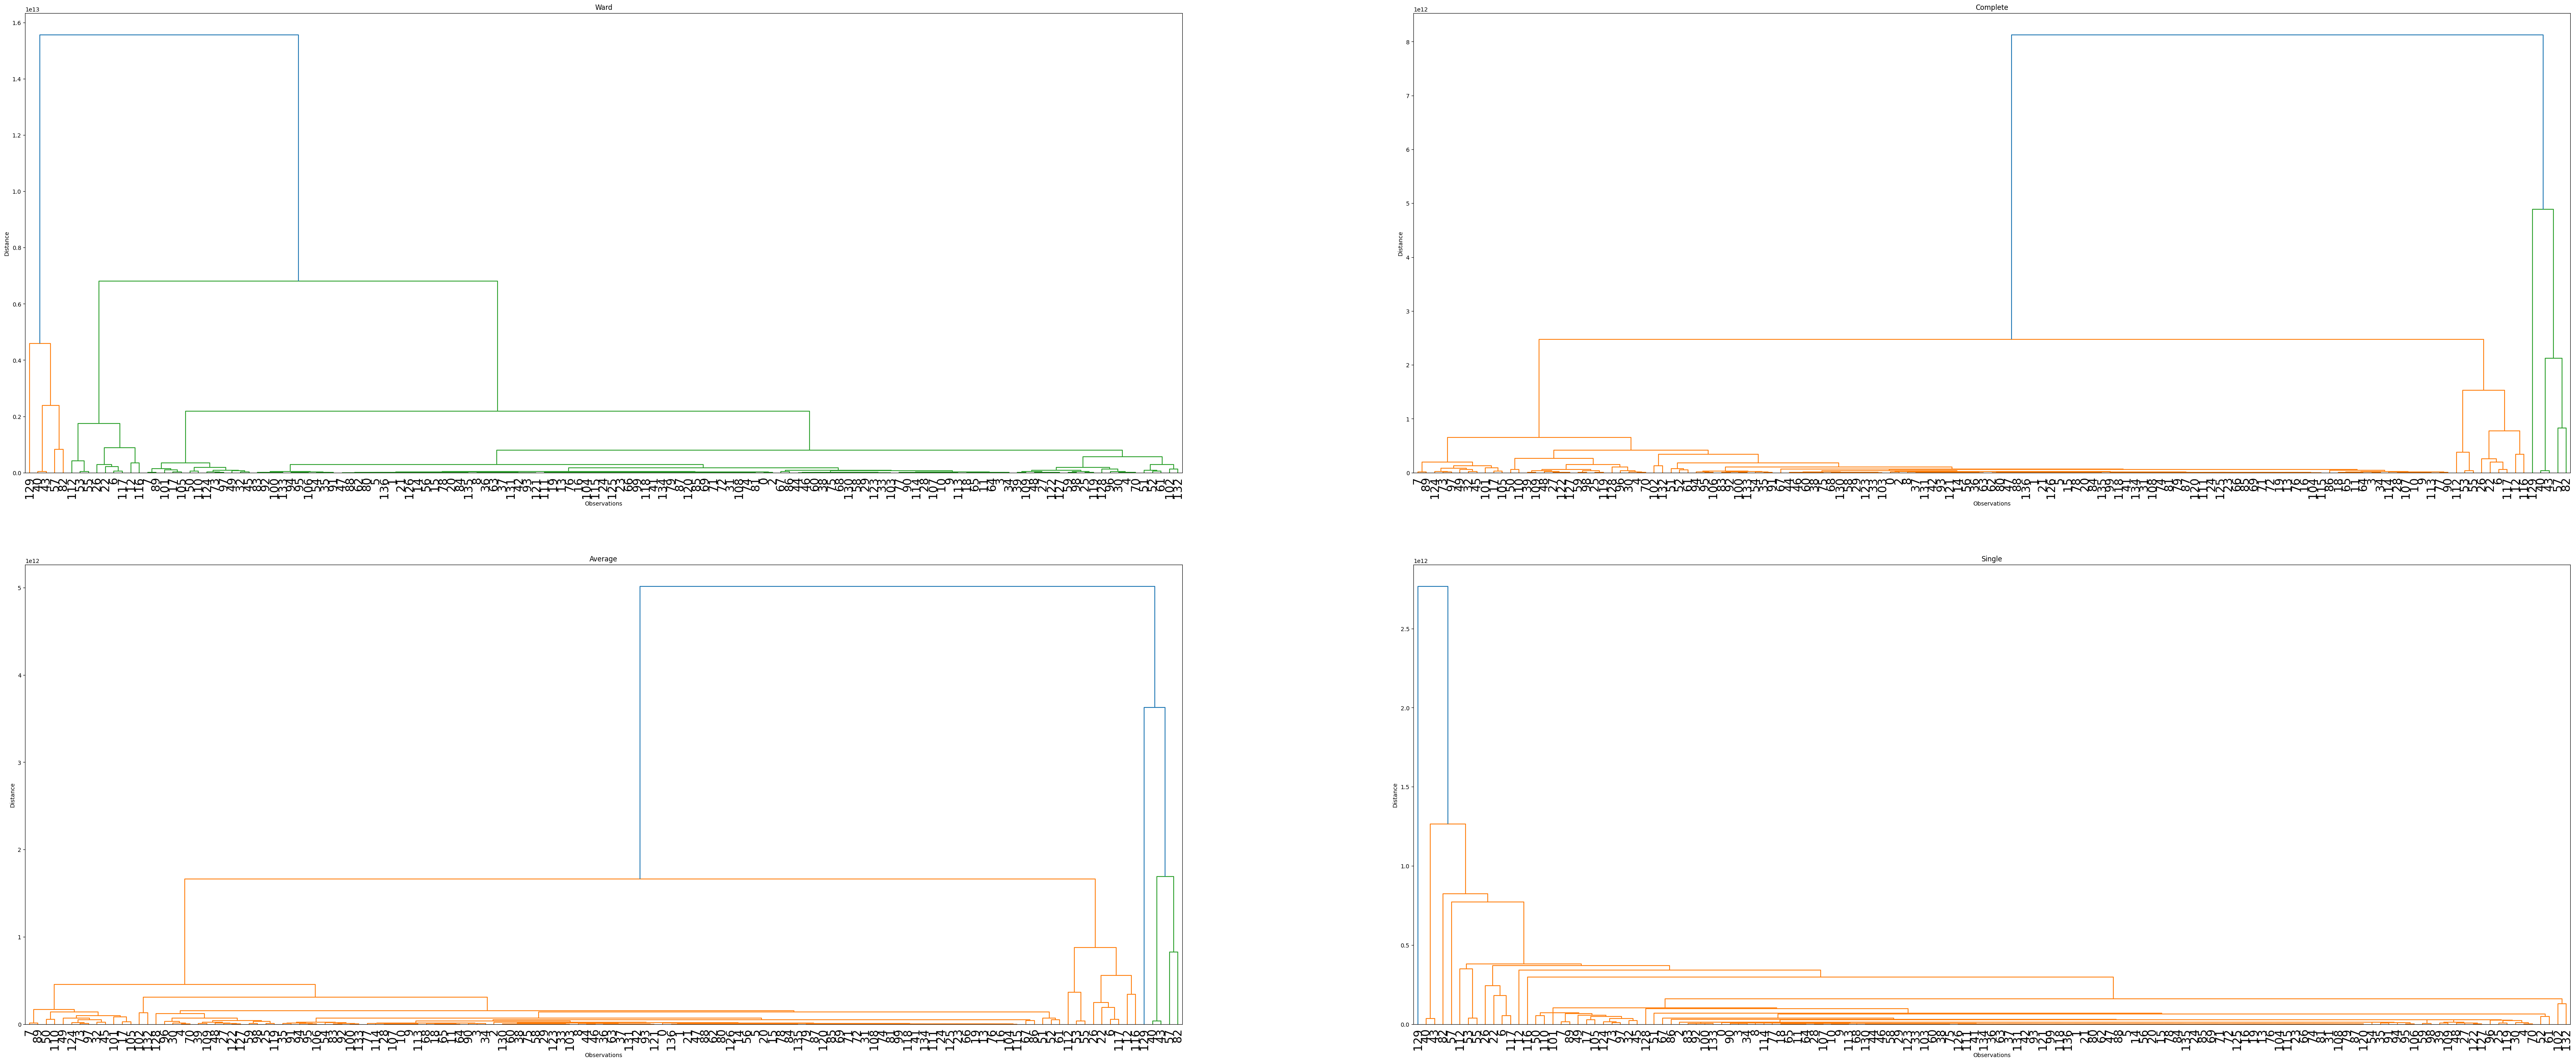

In [34]:

plt.figure(figsize = (80,32))
plt.subplot(221)
plt.title("Ward")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_ward, leaf_font_size = 20)

plt.subplot(222)
plt.title("Complete")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_complete, leaf_font_size = 20)

plt.subplot(223)
plt.title("Average")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_average, leaf_font_size = 20)

plt.subplot(224)
plt.title("Single")
plt.xlabel("Observations")
plt.ylabel("Distance")
dendrogram(hc_single, leaf_font_size = 20);